# Sample H5 file Analysis and Visualization
In this notebook, we anlayze and visualze sample h5 file(s) Thomas generates. 

Before running this notebook, first process the h5 with `data_extractor_crop_SignalBackground.py`

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np
from pathlib import Path
from collections import Counter
import random

# Load data

In [5]:
def load(npz_fname):
    data = np.load(fname)
    adc = data['adc']
    sbg = data['sbg']
    return adc, sbg    

# Statistics and Histograms

In [2]:
def plot_hist(
    stats, 
    xlabel, ylabel, 
    bins=30, 
    logy=False, 
    title=None, 
    save_fname=None, 
    mean_and_median=True
):
    mean = np.mean(stats)
    median = np.median(stats)
    fig, ax = plt.subplots(1, 1)
    ax.hist(stats, bins=bins)
    if mean_and_median:
        ax.axvline(mean, color='orange', label=f'mean = {mean:.6f}')
        ax.axvline(median, color='red', label=f'median = {median:.6f}')
        ax.legend()
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale('log')
    
    if title:
        plt.title(title, fontsize=16)
    if save_fname:
        plt.savefig(save_fname, dpi=200, bbox_inches='tight', transparent=False)

In [3]:
layer_group = 'outer'
fnames = list(Path(layer_group).rglob('*.npz'))
fnames.sort()
print(f'number of files = {len(fnames)}')

number of files = 240


##  Average ADC values

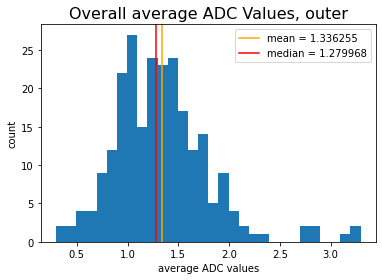

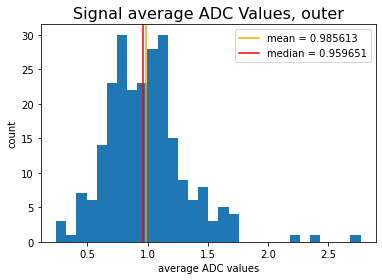

In [6]:
stats_raw, stats_msk = [], []
for fname in fnames:
    adc, sbg = load(fname)    
    stats_raw.append(adc.mean())
    stats_msk.append((adc * sbg).mean())
    
plot_hist(
    stats_raw, 
    xlabel='average ADC values', 
    ylabel='count', 
    title=f'Overall average ADC Values, {layer_group}',
    save_fname=f'images/average_adc_values_overall_{layer_group}.png'
)
plot_hist(
    stats_msk, 
    xlabel='average ADC values', 
    ylabel='count', 
    title=f'Signal average ADC Values, {layer_group}',
    save_fname=f'images/average_adc_values_signal_{layer_group}.png'
)

## Average occupancy

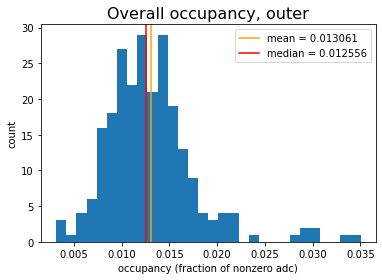

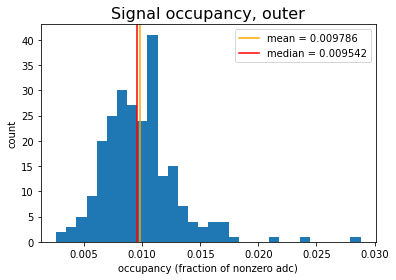

In [7]:
stats_raw, stats_msk = [], []
for fname in fnames:
    adc, sbg = load(fname)
    size = np.product(adc.shape)
    
    nonzero = np.count_nonzero(adc)
    stats_raw.append(nonzero / size)
    
    msk = adc * sbg
    nonzero = np.count_nonzero(msk)
    stats_msk.append(nonzero / size)
    
plot_hist(
    stats_raw, 
    xlabel='occupancy (fraction of nonzero adc)', 
    ylabel='count', 
    title=f'Overall occupancy, {layer_group}',
    save_fname=f'images/occupancy_overall_{layer_group}.png'
)
plot_hist(
    stats_msk, 
    xlabel='occupancy (fraction of nonzero adc)', 
    ylabel='count', 
    title=f'Signal occupancy, {layer_group}',
    save_fname=f'images/occupancy_signal_{layer_group}.png'
)

## Adc value distribution

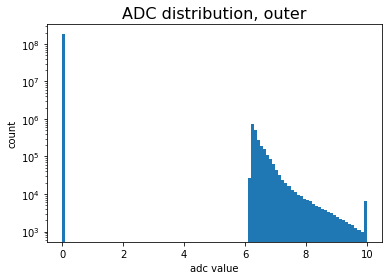

In [8]:
stats = []
for fname in fnames:
    adc, sbg = load(fname)
    stats.append(adc.flatten())
stats = np.array(stats).flatten()
# use the following two lines to control 
# 1. whether to plot log adc values or
# 2. whether to plot positive values only.
stats = np.log2(stats + 1)
# stats = stats[stats > 0]
plot_hist(
    stats, 
    xlabel='adc value', 
    ylabel='count', 
    logy=True, 
    bins=100, 
    title=f'ADC distribution, {layer_group}',
    save_fname=f'images/adc_distribution_{layer_group}.png',
    mean_and_median=False,
)

# Plot 3d frames

In [9]:
def analyze(adc, sbg):
        
    # Signal
    msk_signal = np.logical_and(adc > 0, sbg == 1)
    vec_signal = adc[msk_signal] 
    if len(vec_signal) == 0: 
        vec_signal = np.array([-1])
    
    # Non-signal
    msk_non_signal = np.logical_and(adc > 0, sbg == 0)
    vec_non_signal = adc[msk_non_signal]
    if len(vec_non_signal) == 0:
        vec_non_signal = np.array([-1])

    # a voxel with zero adc but marked as a signal is absurd 
    msk_absurd = np.logical_and(adc == 0, sbg == 1)
    vec_absurd = adc[msk_absurd]
    if len(vec_absurd) == 0:
        vec_absurd = np.array([-1])
    
    result = {
        'signal': vec_signal,
        'non_signal': vec_non_signal,
        'absurd': vec_absurd
    }
        
    return result

In [10]:
def process(image, vmax=None, log=False):
    X, Y, Z = np.argwhere((image >= 1)).T
    values = image[X, Y, Z]
    
    if log:
        values = np.log2(values + 1)
    
    if vmax:
        # Truncate
        values[values > vmax] = vmax
    
    return [X, Y, Z], values

def process_cat(adc, sbg):
    A = np.argwhere(adc * sbg > 0).T
    B = np.argwhere(adc * (1 - sbg) > 0).T
    
    positions = []
    for a, b in zip(A, B):
        positions.append(np.hstack([a, b]))
    values = np.array([1] * len(A[0]) + [0] * len(B[0]))
    
    return positions, values

In [11]:
def plot_3d(
    adc, sbg, 
    vmax        = None, 
    log         = False, 
    image_fname = None, 
    figsize     = (15, 5),
     # choose a cmap that has different and vibrant colors at the extremes
    cmap        = 'viridis'
): 
    positions_cat, values_cat = process_cat(adc, sbg)
    positions_sig, values_sig = process(adc * sbg,       vmax=vmax, log=log)
    positions_nsg, values_nsg = process(adc * (1 - sbg), vmax=vmax, log=log)

    positions = [positions_cat, positions_sig, positions_nsg]
    values    = [values_cat,    values_sig,    values_nsg   ]
    subtitles = ['signal vs non-signal', 'signal', 'non-signal']
    
    subplot_grid = 101 + len(positions) * 10
    
    fig = plt.figure(figsize=figsize)
    for i, (pos, val, subtitle) in enumerate(zip(positions, values, subtitles)):
        ax = fig.add_subplot(subplot_grid + i, projection='3d')
        im=ax.scatter3D(*pos, c=val, s=1, cmap=cmap)
        ax.set_xlim(0, 192)
        ax.set_ylim(0, 249)
        ax.set_zlim(0, 16)
        ax.set_title(subtitle)
        if i == 2:
            result = analyze(adc, sbg)
            text = (
                f"signal mean = {result['signal'].mean():.2f}\n"
                f"nonsignal mean = {result['non_signal'].mean():.2f}\n"
                # f"absurd mean = {result['absurd'].mean():.2f}"
            )
            ax.text2D(0, 0.85, text, transform=ax.transAxes, ha='center')
        
    plt.subplots_adjust(bottom=0.1, right=0.86, top=0.95)
    cax = plt.axes([0.9, 0.25, 0.015, 0.5])
    plt.colorbar(im, cax=cax)
    
    if image_fname:
        fig.suptitle(Path(image_fname).stem, fontsize=12)
        fig.savefig(image_fname, transparent=True, bbox_inches='tight', dpi=200)

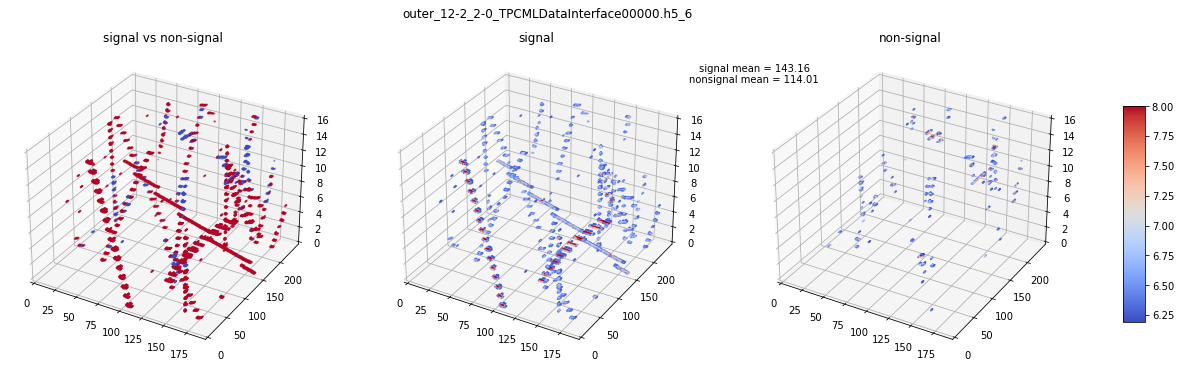

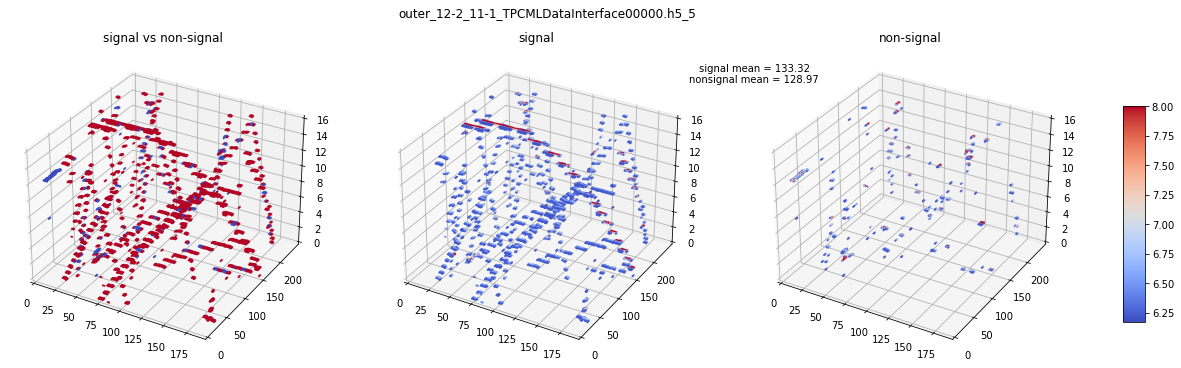

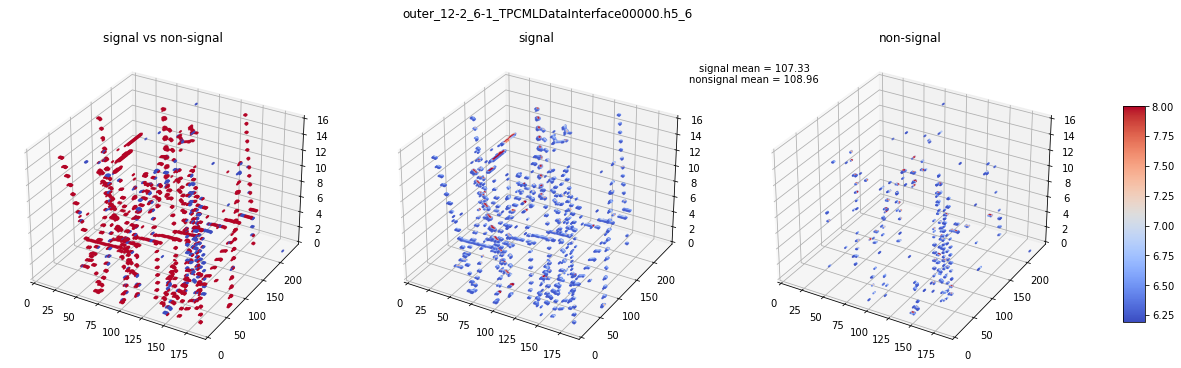

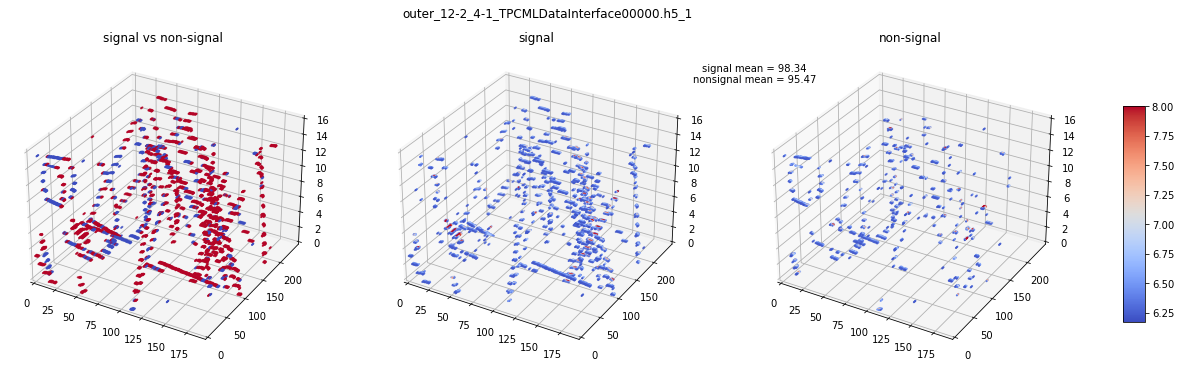

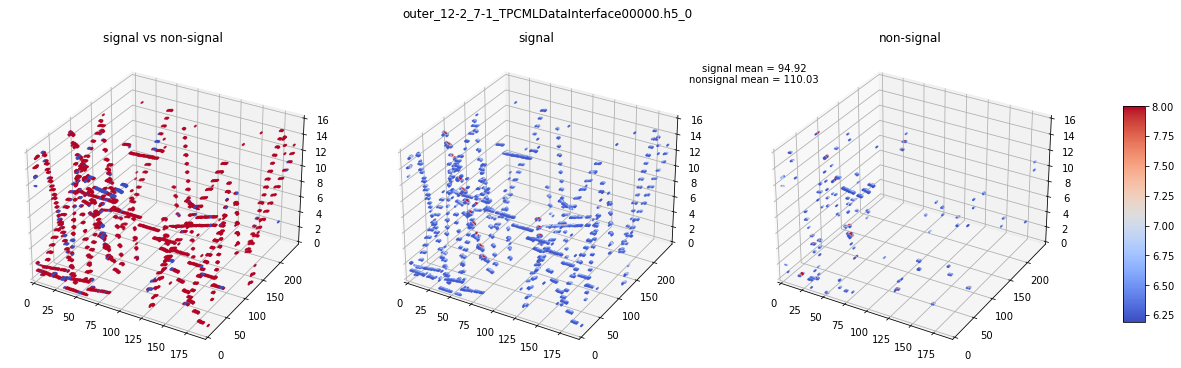

In [12]:
fnames_sel = random.sample(fnames, 5)
for fname in fnames_sel:
    image_fname = str(fname).replace('/', '_')[:-4] + '.png'
    image_fname = f"images/{image_fname}"
    adc, sbg = load(fname)    
    plot_3d(
        adc, sbg, 
        image_fname = image_fname, 
        vmax        = 8, 
        log         = True,
        cmap        = 'coolwarm',
        figsize     = (20, 6)
    )